# Formula 1 Tire Degradation Analysis

By Sami Krothapalli

- This project studies whether Formula 1 tires lose performance gradually or whether there is a tire age where lap times begin to get much worse. 

- The main response variable is `PaceDelta_Adjusted`, which measures how much faster or slower a lap was after accounting for race progress like fuel loss, driver, Grand Prix, and year.


## Step 1: Import Data

The dataset comes from the AeroSpeed Analytics Kaggle dataset. 
- Dataset: https://www.kaggle.com/datasets/shivmahlan/aerospeed-analytics?resource=download


For this project, the main file is `f1_race_laps.csv`
-  Columns:
    - lap time
    - tire life 
    - compound 
    - pit-stop information, 
    - track status
    - driver 
    - race
    - year.


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from patsy import bs

sns.set_theme(style="whitegrid")

data_folder = "data/F1 Dataset"
laps = pd.read_csv(f"{data_folder}/f1_race_laps.csv")

print(laps.shape)
laps.head()


(73398, 24)


,Driver,DriverNumber,Team,LapTime,LapNumber,Compound,TyreLife,FreshTyre,SpeedI1,SpeedI2,...,Sector3Time,PitInTime,PitOutTime,TrackStatus,IsAccurate,GP,Location,Year,Round,HasPitStop
0,VER,1,Red Bull Racing,100.236,1.0,SOFT,4.0,False,230.0,254.0,...,24.389,NaN,NaN,1,False,Bahrain Grand Prix,Sakhir,2022,1,False
1,VER,1,Red Bull Racing,97.880,2.0,SOFT,5.0,False,230.0,252.0,...,24.326,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
2,VER,1,Red Bull Racing,98.357,3.0,SOFT,6.0,False,229.0,254.0,...,24.384,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
3,VER,1,Red Bull Racing,98.566,4.0,SOFT,7.0,False,231.0,250.0,...,24.550,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
4,VER,1,Red Bull Racing,98.877,5.0,SOFT,8.0,False,229.0,256.0,...,24.525,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False


## Step 2: Clean & Validation

### 2a: Race Laps

We only want laps that represent normal dry racing pace and removing everything else


In [67]:
clean_laps = laps.copy()

clean_laps = clean_laps[
    (clean_laps["IsAccurate"] == True) &
    (clean_laps["HasPitStop"] == False) &
    (clean_laps["PitInTime"].isna()) &
    (clean_laps["PitOutTime"].isna()) &
    (clean_laps["TrackStatus"] == 1) &
    (clean_laps["Compound"].isin(["SOFT", "MEDIUM", "HARD"])) &
    (clean_laps["LapTime"].notna()) &
    (clean_laps["TyreLife"].notna())
].copy()

print("Original rows:", laps.shape[0])
print("Rows after cleaning:", clean_laps.shape[0])
clean_laps[["Driver", "GP", "Year", "LapNumber", "LapTime", "Compound", "TyreLife"]].head()


Original rows: 73398
Rows after cleaning: 58521


,Driver,GP,Year,LapNumber,LapTime,Compound,TyreLife
1,VER,Bahrain Grand Prix,2022,2.0,97.880,SOFT,5.0
2,VER,Bahrain Grand Prix,2022,3.0,98.357,SOFT,6.0
3,VER,Bahrain Grand Prix,2022,4.0,98.566,SOFT,7.0
4,VER,Bahrain Grand Prix,2022,5.0,98.877,SOFT,8.0
5,VER,Bahrain Grand Prix,2022,6.0,98.940,SOFT,9.0


### 2b: Validate Data Support by Tire Age

Before interpreting tire degradation, we need to know how many laps exist at each tire age. If a tire age has very few laps, the average pace at that point may be unstable. This is especially important at very high tire ages, where only a few drivers may have completed such long stints.


In [68]:
tire_life_counts = (
    clean_laps
    .groupby(["Compound", "TyreLife"])
    .size()
    .reset_index(name="LapCount")
)

tire_life_counts.head()


,Compound,TyreLife,LapCount
0,HARD,2.0,852
1,HARD,3.0,1020
2,HARD,4.0,1011
3,HARD,5.0,1061
4,HARD,6.0,1082


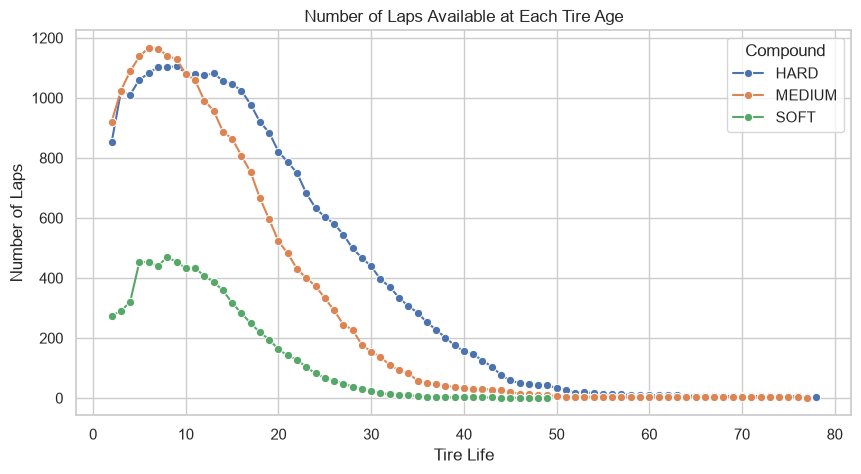

In [69]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tire_life_counts,
    x="TyreLife",
    y="LapCount",
    hue="Compound",
    marker="o"
)

plt.title("Number of Laps Available at Each Tire Age")
plt.xlabel("Tire Life")
plt.ylabel("Number of Laps")
plt.grid(True)
plt.show()


The count plot is a data-quality check, not the main result. It shows that soft tires have fewer long-stint observations, while hard tires are observed over longer tire ages. Because observations become sparse at high tire ages, the analysis keeps only compound/tire-age combinations with at least 30 laps.


In [70]:
reliable_points = tire_life_counts[tire_life_counts["LapCount"] >= 30]

clean_laps_reliable = clean_laps.merge(
    reliable_points[["Compound", "TyreLife"]],
    on=["Compound", "TyreLife"],
    how="inner"
).copy()

print("Rows after cleaning:", clean_laps.shape[0])
print("Rows after reliability filter:", clean_laps_reliable.shape[0])


Rows after cleaning: 58521
Rows after reliability filter: 57891


## Step 4: Create Adjusted Pace Delta

Raw lap time is not a fair response variable because different races have different lap lengths and later race laps are affected by fuel burn. As the car burns fuel, it becomes lighter and can naturally get faster. If we ignore that, older tires might incorrectly look faster simply because they occur later in the race.

To fix this, we first model lap time using race lap number, driver, Grand Prix, and year. The residual from this model becomes `PaceDelta_Adjusted`.

In simple terms:

`PaceDelta_Adjusted = actual lap time - expected lap time after accounting for race context`

Negative values mean the lap was faster than expected. Positive values mean the lap was slower than expected.


In [71]:
clean_laps_reliable = clean_laps_reliable.sort_values(
    ["Year", "Round", "Driver", "LapNumber"]
).copy()

fuel_adjustment_model = smf.ols(
    "LapTime ~ LapNumber + C(Driver) + C(GP) + C(Year)",
    data=clean_laps_reliable
).fit()

clean_laps_reliable["PaceDelta_Adjusted"] = fuel_adjustment_model.resid

clean_laps_reliable[["LapTime", "LapNumber", "TyreLife", "Compound", "PaceDelta_Adjusted"]].head()


,LapTime,LapNumber,TyreLife,Compound,PaceDelta_Adjusted
340,100.548,2.0,2.0,SOFT,-0.478788
341,100.664,3.0,3.0,SOFT,-0.321255
342,101.126,4.0,4.0,SOFT,0.182277
343,102.303,5.0,5.0,SOFT,1.400809
344,101.708,6.0,6.0,SOFT,0.847342


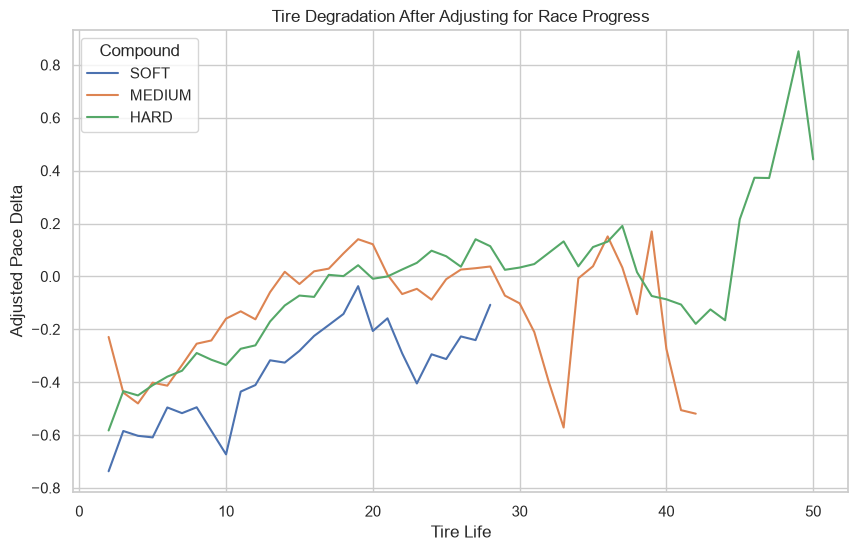

In [72]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=clean_laps_reliable,
    x="TyreLife",
    y="PaceDelta_Adjusted",
    hue="Compound",
    estimator="median",
    errorbar=None
)

plt.title("Tire Degradation After Adjusting for Race Progress")
plt.xlabel("Tire Life")
plt.ylabel("Adjusted Pace Delta")
plt.grid(True)
plt.show()


This plot is the main exploratory degradation plot. It shows the median adjusted pace delta at each tire age for soft, medium, and hard compounds. An upward trend means tires are becoming slower after accounting for race progress and driver/race differences.


## Step 5: Fit a Spline Model

A spline is useful because tire degradation does not have to follow a straight line. Tires may warm up at the beginning of a stint, remain stable for some laps, and then degrade later. The spline model estimates a smooth curve between tire life and adjusted pace delta.


In [ ]:
spline_model = smf.ols(
    "PaceDelta_Adjusted ~ bs(TyreLife, df=6) + C(Compound)",
    data=clean_laps_reliable
).fit()

print(spline_model.summary())


In [ ]:
prediction_data = pd.DataFrame({
    "TyreLife": list(range(2, 51)) * 3,
    "Compound": ["SOFT"] * 49 + ["MEDIUM"] * 49 + ["HARD"] * 49
})

prediction_data["SplinePrediction"] = spline_model.predict(prediction_data)
prediction_data.head()


In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=prediction_data,
    x="TyreLife",
    y="SplinePrediction",
    hue="Compound"
)

plt.title("Spline Model of Tire Degradation")
plt.xlabel("Tire Life")
plt.ylabel("Predicted Adjusted Pace Delta")
plt.grid(True)
plt.show()


## Current Interpretation

The adjusted pace delta plot and spline model suggest that tire performance changes nonlinearly over a stint. The curves improve briefly early in the stint, which may reflect tire warm-up, and then generally rise as tire life increases. A rising curve means the lap is becoming slower than expected after accounting for race progress, driver, Grand Prix, and year.

Soft tires show the highest predicted pace loss, medium tires are in the middle, and hard tires show the lowest predicted pace loss for much of the stint. The sharp rise at high tire ages should be interpreted cautiously because the count plot showed fewer observations at those ages.

At this stage, `PaceDelta_Adjusted` is the response variable that should be used for the remaining methods: segmented regression and regression trees.
